In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re
import nltk
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
import joblib

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dikshya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dikshya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/dikshya/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Loading the datasets

In [2]:
df_fake=pd.read_csv('data/Fake.csv')
df_true=pd.read_csv('data/True.csv')

# Inspecting basic properties

In [3]:
df_fake.describe()

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [4]:
df_true.describe()

,title,text,subject,date
count,21417,21417,21417,21417
unique,20826,21192,2,716
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,14,8,11272,182


In [5]:
df_true['label']=1
df_fake['label']=0

In [7]:
df=pd.concat([df_true,df_fake])

In [8]:
df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [9]:
df=df.drop(['text','subject','date'],axis=1)

In [10]:
df['title']=df['title'].astype(str).str.strip()
df['title']

0        As U.S. budget fight looms, Republicans flip t...
1        U.S. military to accept transgender recruits o...
2        Senior U.S. Republican senator: 'Let Mr. Muell...
3        FBI Russia probe helped by Australian diplomat...
4        Trump wants Postal Service to charge 'much mor...
                               ...                        
23476    McPain: John McCain Furious That Iran Treated ...
23477    JUSTICE? Yahoo Settles E-mail Privacy Class-ac...
23478    Sunnistan: US and Allied ‘Safe Zone’ Plan to T...
23479    How to Blow $700 Million: Al Jazeera America F...
23480    10 U.S. Navy Sailors Held by Iranian Military ...
Name: title, Length: 44898, dtype: str

In [11]:
df.shape

(44898, 2)

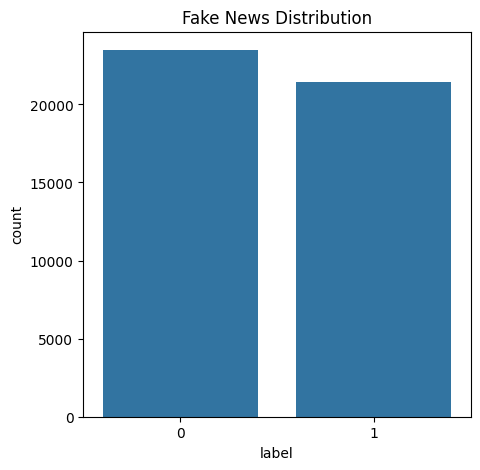

In [12]:
plt.figure(figsize=(5,5))
sns.countplot(x='label', data=df)
plt.title('Fake News Distribution')
plt.show()

In [14]:
df=df.sample(frac=1,random_state=42).reset_index(drop=True)
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [15]:
df["word_count"] = df["title"].apply(lambda x: len(str(x).split()))
df["word_count"].describe()

count    44898.000000
mean        12.453472
std          4.111476
min          1.000000
25%         10.000000
50%         11.000000
75%         14.000000
max         42.000000
Name: word_count, dtype: float64

# Create Text Cleaning Function

In [17]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if type(text) is not str:
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', '', text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Train-test split

In [18]:
X = df['title'].values
y = df['label'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y,test_size = 0.2,random_state=42,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size = 0.5,random_state=42,stratify= y_temp)

# Apply cleaning and lemmatization

In [19]:
lemmatizer = WordNetLemmatizer()

def preprocess_for_lstm(text):
    text = clean_text(text)
    words = [
        lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words
    ]
    return words
    
X_train_tokens = [preprocess_for_lstm(text) for text in X_train]
X_test_tokens = [preprocess_for_lstm(text) for text in X_test]
X_val_tokens = [preprocess_for_lstm(text) for text in X_val]

# Building a vocabulary dictionary

In [20]:
vocab = {"<PAD>":0, "<UNK>": 1}
idx = 2
for tokens in X_train_tokens:
    for token in tokens: 
        if token not in vocab:
            vocab[token] = idx
            idx +=1

print(f"BUILT VOCABULARY \nSIZE OF VOCABULARY: {len(vocab)}")

BUILT VOCABULARY 
SIZE OF VOCABULARY: 31854


# Tokenization and sequencing

In [21]:
def tokens_to_sequences(token_list, vocabulary):
    sequences = []
    for tokens in token_list: 
        seq = [vocabulary.get(token, vocabulary["<UNK>"]) for token in tokens ]
        sequences.append(seq)
    return sequences
    
X_train_seq = tokens_to_sequences(X_train_tokens, vocab)
X_val_seq = tokens_to_sequences(X_val_tokens, vocab)
X_test_seq = tokens_to_sequences(X_test_tokens, vocab)

print(f"raw statement: {X_train[0]}")
print(f"token : {X_train_tokens[0]}")
print(f"sequence : {X_train_seq[0]}")

raw statement: Rubio warms to Trump, but won't be his vice president
token : ['rubiowarmstotrumpbutwontbehisvicepresident']
sequence : [2]


# Padding sequences and Data Loading

In [22]:
MAX_LEN=30

class LSTMDataset(Dataset):
    def __init__(self, sequences, labels, max_len):
        self.labels = torch.tensor(labels, dtype = torch.float32)
        self.max_len = max_len

        padded_sequences = []
        for seq in sequences: 
            if len(seq) < max_len:
                padded = seq + [0]*(max_len- len(seq))
            else: 
                padded = seq[:max_len]
            padded_sequences.append(padded)

        self.sequences = torch.tensor(padded_sequences, dtype = torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self,idx):
        return self.sequences[idx], self.labels[idx]
    
train_dataset = LSTMDataset(X_train_seq, y_train, max_len = MAX_LEN)
test_dataset = LSTMDataset(X_test_seq, y_test, max_len = MAX_LEN)
val_dataset = LSTMDataset(X_val_seq, y_val, max_len = MAX_LEN)

train_loader =DataLoader(train_dataset, batch_size = 64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [39]:
vocab_size = len(vocab)
embedding_dim = 128
hidden_dim = 128
output_dim = 1
num_layers = 2
dropout =0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Creating the LSTM model

In [40]:
class BiLSTMClassifier(nn.Module):
    def __init__ (self, vocab_size, embedding_dim,
                  hidden_dim, output_dim, num_layers,  dropout):
        super(BiLSTMClassifier, self).__init__()

    
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx =0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers = num_layers,
            bidirectional = True,
            dropout = dropout if num_layers> 1 else 0,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim* 2, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)        
        lstm_out, (hidden, cell) = self.lstm(embedded)
        pooled_out = torch.mean(lstm_out, dim= 1)
        logits = self.fc(self.dropout(pooled_out))  
        return logits.squeeze(1)


model  = BiLSTMClassifier(
    vocab_size,
    embedding_dim,
    hidden_dim,
    output_dim,
    num_layers,
    dropout
).to(device)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(31854, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


# Training the LSTM model

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

EPOCHS = 10

history ={
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
}

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    epoch_train_acc = 0
    train_iterator = tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS} [Train]" )

    for batch_x, batch_y in train_iterator:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_x)
        
        loss = criterion(predictions, batch_y)
        acc = binary_accuracy(predictions, batch_y)
        
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        epoch_train_acc += acc.item()
    model.eval()
    epoch_valid_loss = 0
    epoch_valid_acc = 0

    with torch.no_grad():  
        valid_iterator = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
        for batch_x, batch_y in valid_iterator:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            predictions = model(batch_x)

            loss = criterion(predictions, batch_y)
            acc = binary_accuracy(predictions, batch_y)

            epoch_valid_loss += loss.item()
            epoch_valid_acc += acc.item()

  
    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_acc = epoch_train_acc / len(train_loader)
    avg_valid_loss = epoch_valid_loss / len(val_loader)
    avg_valid_acc = epoch_valid_acc / len(val_loader)

    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc)
    history["valid_loss"].append(avg_valid_loss)
    history["valid_acc"].append(avg_valid_acc)
    
print("training completed")

Epoch 10/10 [Valid]: 100%|██████████| 71/71 [00:06<00:00, 10.86it/s]

training completed


# Model Evaluation

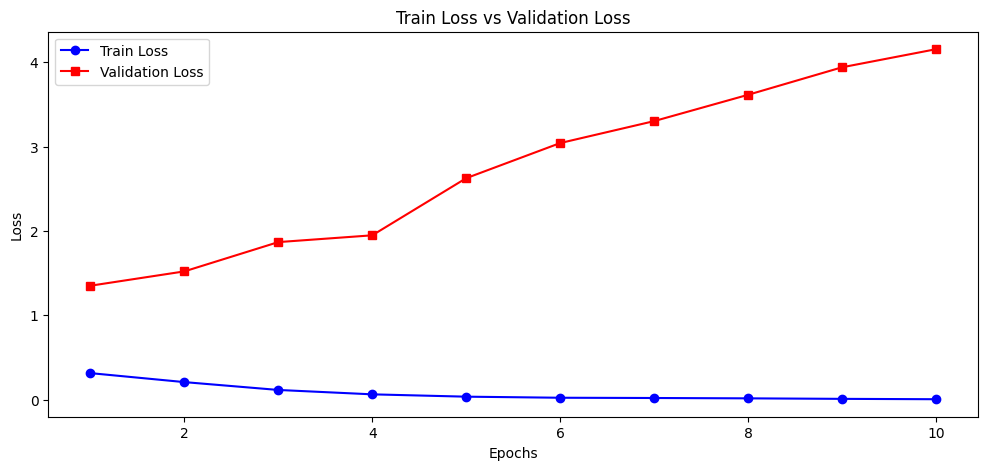

In [69]:
epochs = range(1, 11)
plt.figure(figsize=(12, 5))   
plt.plot(epochs, history["train_loss"], 'b-', label='Train Loss', marker='o')
plt.plot(epochs, history["valid_loss"], 'r-', label='Validation Loss', marker='s')
plt.title(f'Train Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


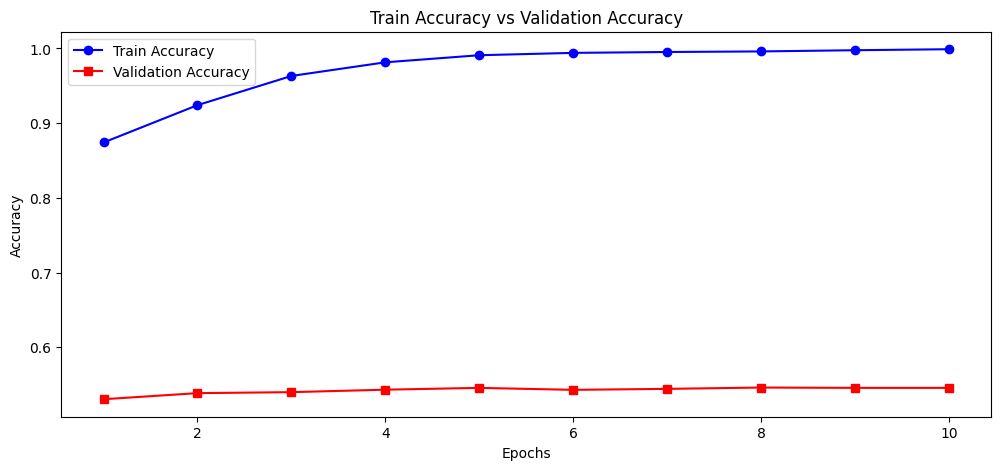

In [70]:
plt.figure(figsize=(12, 5))
plt.plot(epochs, history["train_acc"], 'b-', label='Train Accuracy', marker='o')
plt.plot(epochs, history["valid_acc"], 'r-', label='Validation Accuracy', marker='s')
plt.title(f'Train Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [62]:
model.eval()
    
y_true, y_pred = [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        predictions = model(batch_x)
        preds_classes = torch.round(torch.sigmoid(predictions)).cpu().numpy()  
        y_pred.extend(preds_classes)
        y_true.extend(batch_y.numpy())
            


----------------CLASSIFICATION REPORT----------------
              precision    recall  f1-score   support

         0.0     0.5333    1.0000    0.6956      2348
         1.0     1.0000    0.0406    0.0781      2142

    accuracy                         0.5423      4490
   macro avg     0.7666    0.5203    0.3868      4490
weighted avg     0.7559    0.5423    0.4010      4490



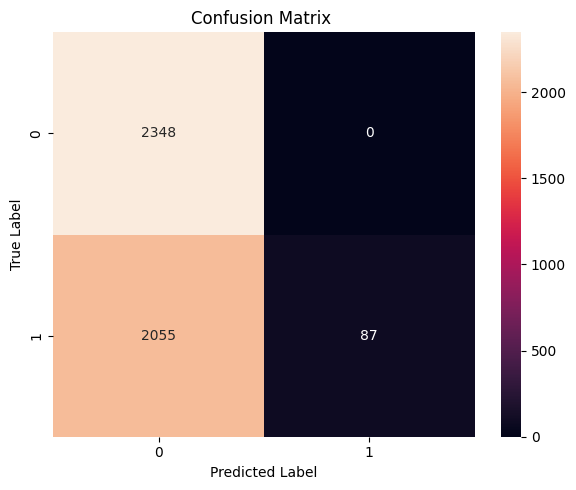

In [68]:

print("----------------CLASSIFICATION REPORT----------------")
print(classification_report(y_true, y_pred, digits=4))  

cm = confusion_matrix(y_true, y_pred)   
plt.figure(figsize=(6, 5))    
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f'Confusion Matrix ')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [73]:
joblib.dump(model, './artifacts/model.pkl')
print("Model saved as model.pkl")

Model saved as model.pkl
